# Создание прогнозных моделей машинного обучения для отбора буренок

Владелец молочного хозяйства «Вольный луг» хочет купить бурёнок, чтобы расширить поголовье стада коров. Для этого он заключил выгодный контракт с ассоциацией пастбищ «ЭкоФерма». Условия позволяют фермеру очень тщательно отобрать коров. Он определяет качество молока по строгой методике, и при этом ему нужно выполнять свой план развития молочного хозяйства. Фермер хочет, чтобы каждая бурёнка давала не менее 6000 килограммов молока в год, а её надой был вкусным. Нам нужно разработать модель машинного обучения, которая поможет ему управлять рисками и принимать объективное решение о покупке.

Таким образом, нам нужно создать две прогнозные модели для отбора бурёнок в поголовье: \
Первая будет прогнозировать возможный удой коровы ; \
Вторая — рассчитывать вероятность получить вкусное молоко от коровы.

С помощью модели нужно отобрать коров по двум критериям:\
средний удой за год — не менее 6000 килограммов;\
молоко должно быть вкусным.

## Первичный анализ данных

In [1]:
!pip install phik -q

In [2]:
#Импортируем все необходимые библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    LabelEncoder
)
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score
)
import phik

In [3]:
#Загружаю необходимые файлы и схораняю их в соответствующие датафреймы
farm_main_df = pd.read_csv('/datasets/ferma_main.csv', sep=';', decimal=',')
farm_dad_df = pd.read_csv('/datasets/ferma_dad.csv', sep=';')
cow_buy_df = pd.read_csv('/datasets/cow_buy.csv', sep=';', decimal=',')

In [4]:
#Вывожу первые 5 строк датафрейма 'farm_main_df' и общую информацию о нем
display(farm_main_df.head(5))
print(farm_main_df.info())

,id,"Удой, кг",ЭКЕ (Энергетическая кормовая единица),"Сырой протеин, г",СПО (Сахаро-протеиновое соотношение),Порода,Тип пастбища,порода папы_быка,"Жирность,%","Белок,%",Вкус молока,Возраст
0,1,5863,14.2,1743,0.890,Вис Бик Айдиал,Равнинное,Айдиал,3.58,3.076,вкусно,более_2_лет
1,2,5529,12.8,2138,0.890,Вис Бик Айдиал,Равнинные,Соверин,3.54,3.079,вкусно,менее_2_лет
2,3,5810,14.0,1854,0.885,РефлешнСоверинг,Холмистое,Соверин,3.59,3.074,не вкусно,более_2_лет
3,4,5895,12.4,2012,0.885,РефлешнСоверинг,Холмистое,Айдиал,3.40,3.075,не вкусно,более_2_лет
4,5,5302,12.8,1675,0.885,Вис Бик Айдиал,Равнинные,Соверин,3.73,3.073,вкусно,менее_2_лет


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 12 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     634 non-null    int64  
 1   Удой, кг                               634 non-null    int64  
 2   ЭКЕ (Энергетическая кормовая единица)  634 non-null    float64
 3   Сырой протеин, г                       634 non-null    int64  
 4   СПО (Сахаро-протеиновое соотношение)   634 non-null    float64
 5   Порода                                 634 non-null    object 
 6   Тип пастбища                           634 non-null    object 
 7   порода папы_быка                       634 non-null    object 
 8   Жирность,%                             634 non-null    float64
 9   Белок,%                                634 non-null    float64
 10  Вкус молока                            634 non-null    object 
 11  Возрас

**Вывод:** В датафрейме farm_main_df содержатся данные о стаде фермера на текущий момент. Всего в датафрейме 634 значения и 12 параметров: 
- id — уникальный идентификатор коровы; 
- Удой, кг — масса молока, которую корова даёт в год (в килограммах); 
- ЭКЕ (Энергетическая кормовая единица) — показатель питательности корма коровы;
- Сырой протеин, г — содержание сырого протеина в корме (в граммах);
- СПО (Сахаро-протеиновое соотношение) — отношение сахара к протеину в корме коровы;
- Порода — порода коровы;
- Тип пастбища — ландшафт лугов, на которых паслась корова;
- порода папы_быка — порода папы коровы;
- Жирность,% — содержание жиров в молоке (в процентах);
- Белок,% — содержание белков в молоке (в процентах);
- Вкус молока — оценка вкуса по личным критериям фермера, бинарный признак (вкусно, не вкусно);
- Возраст — возраст коровы, бинарный признак (менее_2_лет, более_2_лет). 

Столбцы имеют верный тип данных.

In [5]:
#Вывожу первые 5 строк датафрейма 'farm_dad_df' и общую информацию о нем
display(farm_dad_df.head(5))
print(farm_dad_df.info())

,id,Имя Папы
0,1,Буйный
1,2,Соловчик
2,3,Барин
3,4,Буйный
4,5,Барин


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        629 non-null    int64 
 1   Имя Папы  629 non-null    object
dtypes: int64(1), object(1)
memory usage: 10.0+ KB
None


**Вывод:** В датафрейме farm_dad_df содержатся данные об имени папы каждой коровы в стаде фермера. Всего в датафрейме 629 значениий и 2 параметра:
- id — уникальный идентификатор коровы; 
- Имя Папы — имя папы коровы.

In [6]:
#Вывожу первые 5 строк датафрейма 'cow_buy_df' и общую информацию о нем
display(cow_buy_df.head(5))
print(cow_buy_df.info())

,Порода,Тип пастбища,порода папы_быка,Имя_папы,"Текущая_жирность,%","Текущий_уровень_белок,%",Возраст
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Порода                   20 non-null     object 
 1   Тип пастбища             20 non-null     object 
 2   порода папы_быка         20 non-null     object 
 3   Имя_папы                 20 non-null     object 
 4   Текущая_жирность,%       20 non-null     float64
 5   Текущий_уровень_белок,%  20 non-null     float64
 6   Возраст                  20 non-null     object 
dtypes: float64(2), object(5)
memory usage: 1.2+ KB
None


**Вывод:** В датафрейме cow_buy_df содержатся данные о коровах «ЭкоФермы», которых фермер хочет изучить перед покупкой. Всего в датафрейме 20 значениий и 7 параметров:
- Порода — порода коровы;
- Тип пастбища — ландшафт лугов, на которых паслась корова;
- порода папы_быка — порода папы коровы;
- Имя_папы — имя папы коровы;
- Текущая_жирность,% — содержание жиров в молоке (в процентах);
- Текущий_уровень_белок,% — содержание белков в молоке (в процентах);
- Возраст — возраст коровы, бинарный признак (менее_2_лет, более_2_лет). 

Все столбцы имеют верный тип данных.

## Предобработка данных

In [7]:
#Проверяю наличие пропущенных значений в датафреймах
print(farm_main_df.isna().sum())
print(farm_dad_df.isna().sum())
print(cow_buy_df.isna().sum())

id                                       0
Удой, кг                                 0
ЭКЕ (Энергетическая кормовая единица)    0
Сырой протеин, г                         0
СПО (Сахаро-протеиновое соотношение)     0
Порода                                   0
Тип пастбища                             0
порода папы_быка                         0
Жирность,%                               0
Белок,%                                  0
Вкус молока                              0
Возраст                                  0
dtype: int64
id          0
Имя Папы    0
dtype: int64
Порода                     0
Тип пастбища               0
порода папы_быка           0
Имя_папы                   0
Текущая_жирность,%         0
Текущий_уровень_белок,%    0
Возраст                    0
dtype: int64


**Вывод:** В датафреймах нет пропущенных значений

In [8]:
#Проверяю наличие неявных дубликатов в датафрейме farm_main_df
farm_main_dub_check = ['Порода', 'Тип пастбища', 'порода папы_быка', 'Вкус молока', 'Возраст']
for c in farm_main_dub_check:
    print(farm_main_df[c].unique())

['Вис Бик Айдиал' 'РефлешнСоверинг']
['Равнинное' 'Равнинные' 'Холмистое']
['Айдиал' 'Соверин' 'Айдиалл']
['вкусно' 'не вкусно']
['более_2_лет' 'менее_2_лет']


In [9]:
#Убираю неявные дубликаты в датафрейме farm_main_df
farm_main_df['Тип пастбища'] = farm_main_df['Тип пастбища'].str.replace('Равнинные','Равнинное')
farm_main_df['порода папы_быка'] = farm_main_df['порода папы_быка'].str.replace('Айдиалл', 'Айдиал')
#Перевожу значения в'Тип пастбища' к нижнему регистру
farm_main_df['Тип пастбища'] = farm_main_df['Тип пастбища'].str.lower()

**Вывод:** В датафрейме farm_main_df есть неявные дубликаты в столбцах 'Тип пастбища' и 'порода папы_быка'. Они были заменены соответствующими значениями. Также в столбце 'Тип пастбища' значения были приведены к нижнему регистру.

In [10]:
#Проверяю наличие неявных дубликатов в датафрейме farm_dad_df
print(farm_dad_df['Имя Папы'].unique())

['Буйный' 'Соловчик' 'Барин' 'Геркулес']


In [11]:
#Проверяю наличие неявных дубликатов в датафрейме cow_buy_df
cow_buy_df_dub_check = ['Порода', 'Тип пастбища', 'порода папы_быка','Возраст']
for c in cow_buy_df_dub_check:
    print(cow_buy_df[c].unique())

['Вис Бик Айдиал' 'РефлешнСоверинг']
['холмистое' 'равнинное']
['Айдиал' 'Соверин']
['более_2_лет' 'менее_2_лет']


**Вывод:** В датафреймах farm_dad_df и cow_buy_df нет неявных дубликатов.

In [12]:
#Проверяю наличие явных дубликатов в датафреймах 
print('Кол-во явных дубликатов в farm_main_df', farm_main_df.duplicated().sum())
print('Кол-во явных дубликатов в farm_dad_df', farm_dad_df.duplicated().sum())
print('Кол-во явных дубликатов в cow_buy_df', cow_buy_df.duplicated().sum())

Кол-во явных дубликатов в farm_main_df 5
Кол-во явных дубликатов в farm_dad_df 0
Кол-во явных дубликатов в cow_buy_df 4


**Вывод:** В датафреймах farm_main_df и cow_buy_df были выявлены явные дубликаты, однако они не были удалены, чтобы сохранить важную информацию для более точного предсказания.

**Общий вывод:** Была проведена предобробатка данных, в ходе чего неявные дубликаты в столбцах 'Тип пастбища' и 'порода папы_быка' в датафрейме farm_main_df были заменены на соответствующие значения, а явные дубликаты оставлены для более точного предсказания. 

## Исследовательский анализ данных

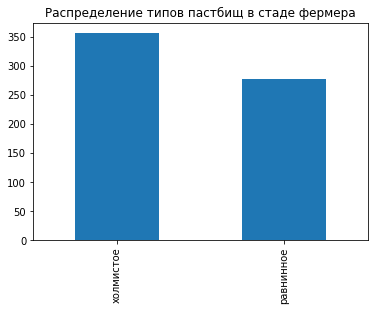

In [13]:
#Строю столбчатую диаграмму для параметра 'тип пастбища' в датафрейме farm_main_df
farm_main_df['Тип пастбища'].value_counts().plot(kind='bar', title='Распределение типов пастбищ в стаде фермера');

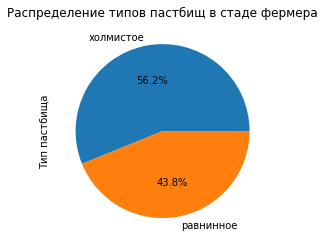

In [14]:
farm_main_df['Тип пастбища'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Распределение типов пастбищ в стаде фермера');

**Вывод:** По графику видно, что в стаде фермера немного преобладает холмистое пастбище, насчитывающее около 350 значений (55.8%), в отличие от равнинного типа пастбища, которое составляет примерно 275 значений(44.2%).

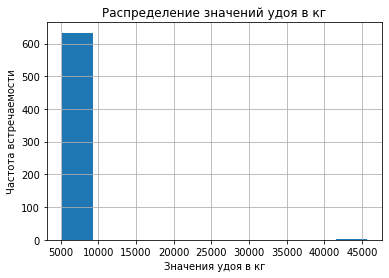

In [15]:
#Строю гистограмму для параметра 'Удой, кг' в датафрейме farm_main_df
farm_main_df['Удой, кг'].hist()
plt.title('Распределение значений удоя в кг')
plt.xlabel('Значения удоя в кг')
plt.ylabel('Частота встречаемости')
plt.show()

In [16]:
#Проверяю кол-во аномальных значений в столбце 'Удой, кг' в датафрейме farm_main_df
print("Кол-во аномальных значений в столбце 'Удой, кг':", farm_main_df[farm_main_df['Удой, кг'] > 8000]['Удой, кг'].count())

Кол-во аномальных значений в столбце 'Удой, кг': 1


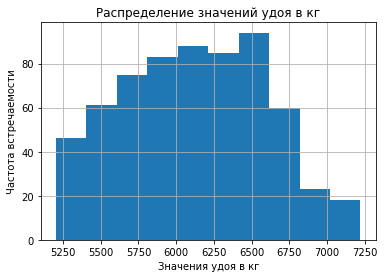

In [17]:
#Удаляю аномальные значения для параметра 'Удой, кг' в датафрейме farm_main_df
farm_main_df = farm_main_df[farm_main_df['Удой, кг'] < 40000]
#Строю гистограмму для параметра 'Удой, кг' в датафрейме farm_main_df после удаления аномальных значений
farm_main_df['Удой, кг'].hist()
plt.title('Распределение значений удоя в кг')
plt.xlabel('Значения удоя в кг')
plt.ylabel('Частота встречаемости')
plt.show()

**Вывод:** По первой гистограмме можно отметить, что в столбце 'Удой, кг' датафрейма farm_main_df большинство значений сосредоточено в диапазоне от 5000 до 7250 кг. Также были выявлены аномальные значения, превышающие 40000 кг, которые были удалены. На второй гистограмме видно, что распределение значений близко к нормальному, при этом пик находится в диапазоне от 6000 до 6600.

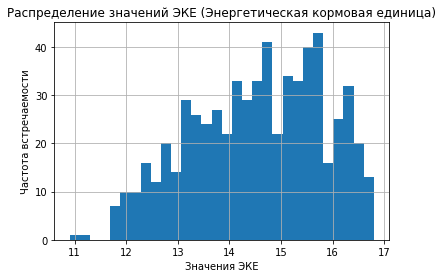

In [18]:
#Строю гистограмму для параметра 'ЭКЕ (Энергетическая кормовая единица)' в датафрейме farm_main_df
farm_main_df['ЭКЕ (Энергетическая кормовая единица)'].hist(bins=30) 
plt.title('Распределение значений ЭКЕ (Энергетическая кормовая единица)')
plt.xlabel('Значения ЭКЕ')
plt.ylabel('Частота встречаемости')
plt.show()

In [19]:
#Проверяю кол-во аномальных значений в столбце 'ЭКЕ (Энергетическая кормовая единица)' в датафрейме farm_main_df
print("Кол-во аномальных значений в столбце 'ЭКЕ (Энергетическая кормовая единица)':", farm_main_df[farm_main_df['ЭКЕ (Энергетическая кормовая единица)'] < 11.5]['ЭКЕ (Энергетическая кормовая единица)'].count())

Кол-во аномальных значений в столбце 'ЭКЕ (Энергетическая кормовая единица)': 2


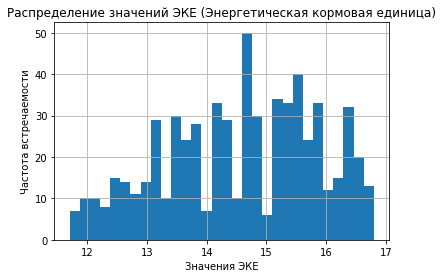

In [20]:
#Удаляю аномальные значения для параметра 'ЭКЕ (Энергетическая кормовая единица)' в датафрейме farm_main_df
farm_main_df = farm_main_df[farm_main_df['ЭКЕ (Энергетическая кормовая единица)'] > 11.5]
#Строю гистограмму для параметра 'ЭКЕ (Энергетическая кормовая единица)' в датафрейме farm_main_df после удаления аномальных значений
farm_main_df['ЭКЕ (Энергетическая кормовая единица)'].hist(bins=30) 
plt.title('Распределение значений ЭКЕ (Энергетическая кормовая единица)')
plt.xlabel('Значения ЭКЕ')
plt.ylabel('Частота встречаемости')
plt.show()

**Вывод:** На первой гистограмме видно, что в столбце 'ЭКЕ (Энергетическая кормовая единица)' датафрейма farm_main_df большинство значений сосредоточено в диапазоне от 11.5 до 17. Также были удалены аномальные значения, которые были меньше 11.5. На второй гистограмме видно, что пик находится в промежутке между значениями 14 и 15.

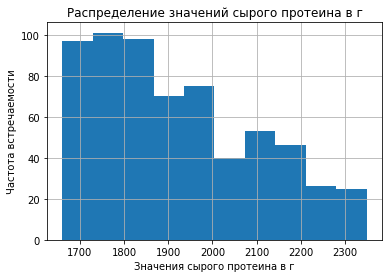

In [21]:
#Строю гистограмму для параметра 'Сырой протеин, г' в датафрейме farm_main_df
farm_main_df['Сырой протеин, г'].hist()
plt.title('Распределение значений сырого протеина в г')
plt.xlabel('Значения сырого протеина в г')
plt.ylabel('Частота встречаемости')
plt.show()

**Вывод:** По гистограмме видно, что значения содержания сырого протеина в молоке стада фермера находятся в диапазоне от 1600 до 2400 г, с пиком в районе от 1700 до 1800 г.

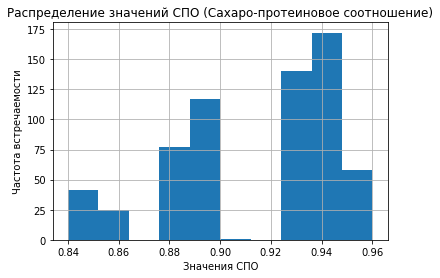

In [22]:
#Строю гистограмму для параметра 'СПО (Сахаро-протеиновое соотношение)' в датафрейме farm_main_df
farm_main_df['СПО (Сахаро-протеиновое соотношение)'].hist()
plt.title('Распределение значений СПО (Сахаро-протеиновое соотношение)')
plt.xlabel('Значения СПО')
plt.ylabel('Частота встречаемости')
plt.show()

In [23]:
#Проверяю кол-во аномальных значений в столбце 'СПО (Сахаро-протеиновое соотношение)' в датафрейме farm_main_df
print("Кол-во аномальных значений в столбце 'СПО (Сахаро-протеиновое соотношение)':", farm_main_df[(0.9 <= farm_main_df['СПО (Сахаро-протеиновое соотношение)']) & (farm_main_df['СПО (Сахаро-протеиновое соотношение)'] <= 0.92)]['СПО (Сахаро-протеиновое соотношение)'].count())

Кол-во аномальных значений в столбце 'СПО (Сахаро-протеиновое соотношение)': 1


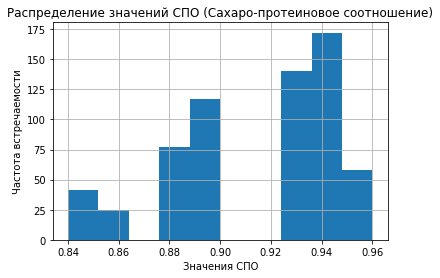

In [24]:
#Удаляю аномальные значения для параметра 'СПО (Сахаро-протеиновое соотношение)' в датафрейме farm_main_df
farm_main_df = farm_main_df[~((0.9 <= farm_main_df['СПО (Сахаро-протеиновое соотношение)']) & (farm_main_df['СПО (Сахаро-протеиновое соотношение)'] <= 0.92))]
#Строю гистограмму для параметра 'СПО (Сахаро-протеиновое соотношение)' в датафрейме farm_main_df после удаления аномальных значений
farm_main_df['СПО (Сахаро-протеиновое соотношение)'].hist() 
plt.title('Распределение значений СПО (Сахаро-протеиновое соотношение)')
plt.xlabel('Значения СПО')
plt.ylabel('Частота встречаемости')
plt.show()

**Вывод:** На первой гистограмме видно, что в столбце 'СПО (Сахаро-протеиновое соотношение)' датафрейма farm_main_df большинство значений сосредоточено в диапазоне от 0.92 до 0.96. Аномальные значения, находившиеся в промежутке от 0.9 до 0.92, были удалены. На второй гистограмме видно, что все оставшиеся значения распределены по трем основным промежуткам. Наибольшее количество значений сосредоточено в интервале от 0.92 до 0.96, немного меньше — в промежутке от 0.87 до 0.90, а наименьшее количество значений — в диапазоне от 0.84 до 0.87.

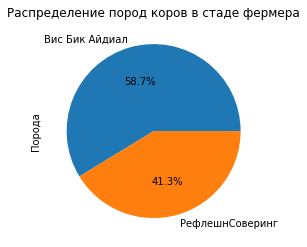

In [25]:
#Строю круговую диаграмму для параметра 'Порода' в датафрейме 'farm_main_df'
farm_main_df['Порода'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Распределение пород коров в стаде фермера'); 

**Вывод:** Видно, что в стаде фермера порода Вис Бик Айдиал немного преобладает над РефлешнСоверинг.

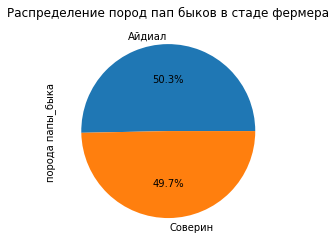

In [26]:
#Строю круговую диаграмму для параметра 'порода папы_быка' в датафрейме 'farm_main_df'
farm_main_df['порода папы_быка'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Распределение пород пап быков в стаде фермера');

**Вывод:** В стаде фермера две породы отцов быков представлены примерно в равных пропорциях.

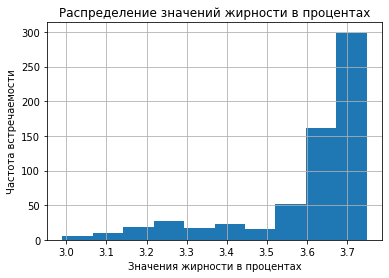

In [27]:
#Строю гистограмму для параметра 'Жирность,%' в датафрейме farm_main_df
farm_main_df['Жирность,%'].hist()
plt.title('Распределение значений жирности в процентах')
plt.xlabel('Значения жирности в процентах')
plt.ylabel('Частота встречаемости')
plt.show()

**Вывод:** В стаде фермера жирность молока варьируется от 2.9% до 3.8%, при этом наибольшее количество значений наблюдается около 3.7%.

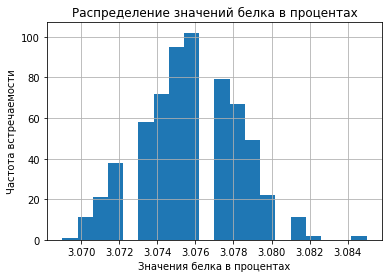

In [28]:
#Строю гистограмму для параметра 'Белок,%' в датафрейме farm_main_df
farm_main_df['Белок,%'].hist(bins=20)
plt.title('Распределение значений белка в процентах')
plt.xlabel('Значения белка в процентах')
plt.ylabel('Частота встречаемости')
plt.show()

In [29]:
#Проверяю кол-во аномальных значений в столбце 'Белок,%' в датафрейме farm_main_df
print("Кол-во аномальных значений в столбце 'Белок,%':", farm_main_df[farm_main_df['Белок,%'] > 3.083]['Белок,%'].count())

Кол-во аномальных значений в столбце 'Белок,%': 2


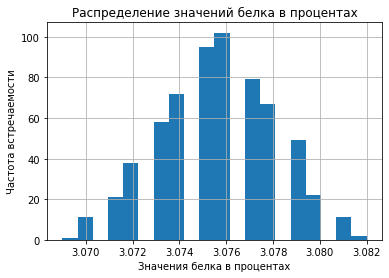

In [30]:
#Удаляю аномальные значения для параметра 'Белок,%' в датафрейме farm_main_df
farm_main_df = farm_main_df[farm_main_df['Белок,%'] < 3.083]
#Строю гистограмму для параметра 'Белок,%' в датафрейме farm_main_df после удаления аномальных значений
farm_main_df['Белок,%'].hist(bins=20) 
plt.title('Распределение значений белка в процентах')
plt.xlabel('Значения белка в процентах')
plt.ylabel('Частота встречаемости')
plt.show()

**Вывод:** В стаде фермера содержание белка находится в диапазоне от 3.068 % до 3.086 %, с наибольшим кол-вом значений в районе около 3.075 - 3.076 %. Были также удалены 2 аномальных значения, которые превышали 3.083%.

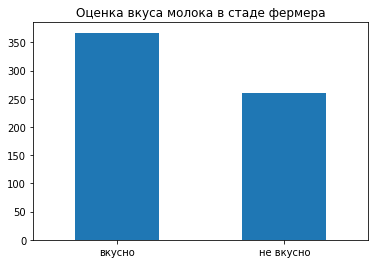

In [31]:
#Строю столбчатую диаграмму для параметра 'Вкус молока' в датафрейме farm_main_df
farm_main_df['Вкус молока'].value_counts().plot(kind='bar')
plt.title('Оценка вкуса молока в стаде фермера')
plt.xticks(rotation=0)
plt.show()

**Вывод:** В стаде фермера преобладает вкусное молоко(350 значений) над невкусным (250 значений).

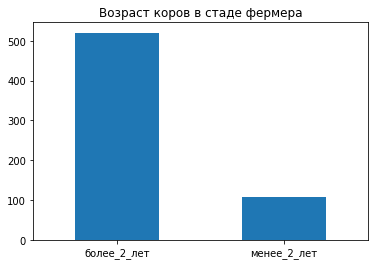

In [32]:
#Строю столбчатую диаграмму для параметра 'Возраст' в датафрейме farm_main_df
farm_main_df['Возраст'].value_counts().plot(kind='bar')
plt.title('Возраст коров в стаде фермера')
plt.xticks(rotation=0)
plt.show()

 **Вывод:** Большинство коров в стаде фермера имеют возраст более 2 лет (500 значений).

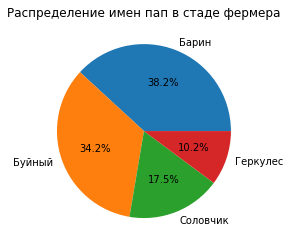

In [33]:
#Строю круговую диаграмму для параметра 'Имя Папы' в датафрейме farm_dad_df
farm_dad_df['Имя Папы'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Распределение имен пап в стаде фермера')
plt.ylabel('');

**Вывод:** По диаграмме видно, что наибольшее количество потомства дает бык Барин (38,2%), следом идет бык Буйный с примерно таким же результатом (34,2%).Треть потомства дают быки Соловчик (17.5) и Геркулес(10.2).

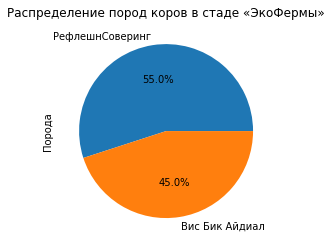

In [34]:
#Строю круговую диаграмму для параметра 'Порода' в датафрейме cow_buy_df
cow_buy_df['Порода'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Распределение пород коров в стаде «ЭкоФермы»');

**Вывод:** В 'Экоферме' преобладает порода РефлишСоверинг (55%) над Вис Бик Айдиал (45%).

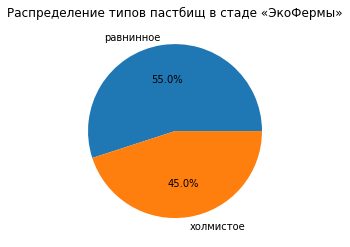

In [35]:
#Строю круговую диаграмму для параметра 'Тип пастбища' в датафрейме cow_buy_df
cow_buy_df['Тип пастбища'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Распределение типов пастбищ в стаде «ЭкоФермы»')
plt.ylabel('');

**Вывод:** В 'Экоферме' преобладает равнинное пастбище (55%) над холмистым (45%).

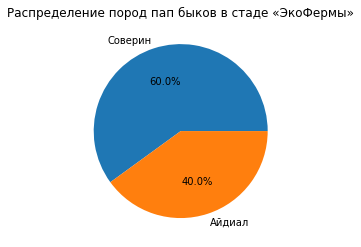

In [36]:
#Строю круговую диаграмму для параметра 'Тип пастбища' в датафрейме cow_buy_df
cow_buy_df['порода папы_быка'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Распределение пород пап быков в стаде «ЭкоФермы»')
plt.ylabel('');

**Вывод:** В 'Экоферме' преобладает порода Соверин (60%) над Айдиал (40%).

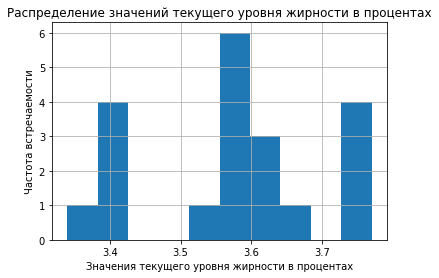

In [37]:
#Строю гистограмму для параметра 'Текущая_жирность,%' в датафрейме cow_buy_df
cow_buy_df['Текущая_жирность,%'].hist()
plt.title('Распределение значений текущего уровня жирности в процентах')
plt.xlabel('Значения текущего уровня жирности в процентах')
plt.ylabel('Частота встречаемости')
plt.show()

**Вывод:** В 'Экоферме' текущая жирность молока распределена по трем диапазонам: от 3.3 до 3.45, от 3.5 до 3.7 и от 3.7 до 3.8, при этом наибольшее количество значений наблюдается в промежутке от 3.5 до 3.7.

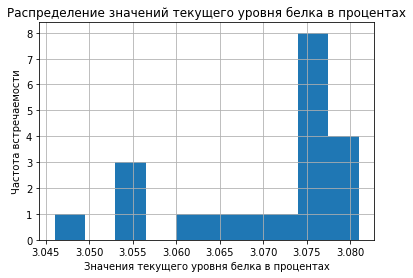

In [38]:
#Строю гистограмму для параметра 'Текущий_уровень_белок,%' в датафрейме cow_buy_df
cow_buy_df['Текущий_уровень_белок,%'].hist()
plt.title('Распределение значений текущего уровня белка в процентах')
plt.xlabel('Значения текущего уровня белка в процентах')
plt.ylabel('Частота встречаемости')
plt.show()

**Вывод:** В 'Экоферме' текущий уровень белка в молоке распределен по трем диапазонам: от 3.045 до 3.05, от 3.053 до 3.056 и от 3.06 до 3.82, при этом наибольшее количество значений наблюдается в промежутке от 3.06 до 3.82.

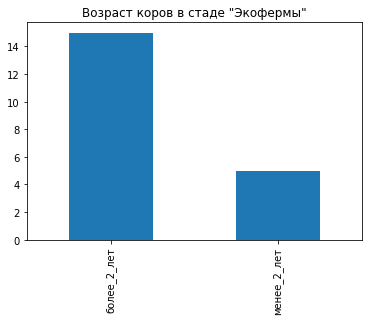

In [39]:
#Строю столбчатую диаграмму для параметра 'Возраст' в датафрейме cow_buy_df
cow_buy_df['Возраст'].value_counts().plot(kind='bar')
plt.title('Возраст коров в стаде "Экофермы"')
plt.show()

**Вывод:**  Большинство коров в 'Экоферме' имеют возраст более 2 лет.

**Общий вывод:** В ходе проведенного исследовательского анализа было установлено, что в стаде фермера преобладает порода коров Бик Айдиал, которая предпочитает холмистые пастбища. В то же время на 'Экоферме'основную часть стада составляют коровы породы РефлешнСеверинг, предпочитающие равнинные пастбища. В обоих стадах коровы в основном старше двух лет. Также было выявлено, что молоко коров на «Экоферме» более жирное, чем у фермера, при этом содержание белка в молоке в обоих стадах находится в одинаковом диапазоне.

## Корреляционный анализ

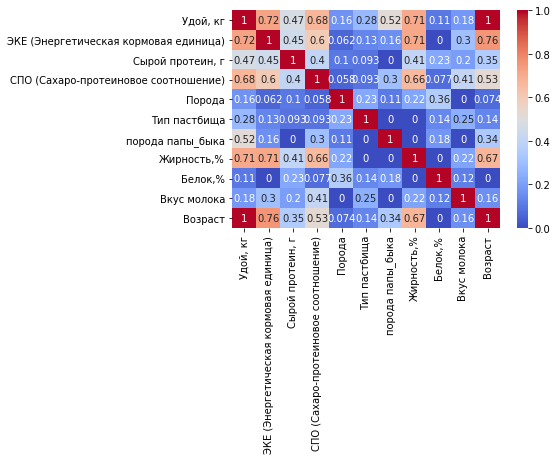

In [40]:
#Рассчитываю коэффициенты корреляциями между параметрами в датафрейме farm_main_df
corr_matrix = farm_main_df.drop(columns=['id']).phik_matrix(interval_cols = ['Удой, кг', 'ЭКЕ (Энергетическая кормовая единица)','Сырой протеин, г','СПО (Сахаро-протеиновое соотношение)','Жирность,%','Белок,%'])
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm");

**Вывод:** По таблице корреляции можно сделать следующие выводы:

Параметр ЭКЕ имеет сильную положительную корреляцию с возрастом (0.77), СПО(0.59) и жирностью (0.72). Также между ЭКЕ и сырым протеином наблюдается средняя положительная корреляция (0.47).

СПО имеет наибольшее количество сильных корреляций с другими параметрами: с возрастом (0.77), ЭКЕ (0.59), вкусом молока(0.57) и жирностью (0.72). Также наблюдается умеренная корреляция между данным параметром и породой быков (0.43), а также с содержанием сырого протеина (0.39).

Жирность, в свою очередь, имеет сильную положительную корреляцию с ЭКЕ (0.72), СП0 (0.65) и возрастом (0.67).

В целом, параметры ЭКЕ, жирность, возраст и СПО тесно взаимосвязаны между собой.

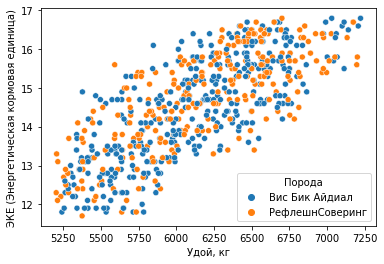

In [41]:
#Строю диаграмму рассеяния для параметров 'Удой, кг' и 'ЭКЕ (Энергетическая кормовая единица)' c учетом категориального параметроа 'Порода'
sns.scatterplot(data=farm_main_df, x='Удой, кг', y='ЭКЕ (Энергетическая кормовая единица)', hue='Порода', sizes=(50, 50), legend=True);


**Вывод:** Порода не оказывает значительного влияния на удой и ЭКЕ, однако между удоем и ЭКЕ наблюдается выраженная положительная линейная связь.

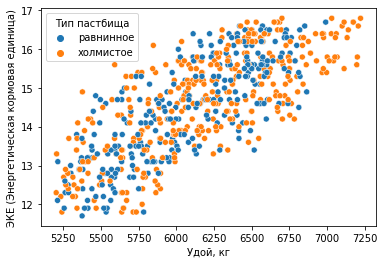

In [42]:
#Строю диаграмму рассеяния для параметров 'Удой, кг' и 'ЭКЕ (Энергетическая кормовая единица)' c учетом категориального параметра 'Тип пастбища'
sns.scatterplot(data=farm_main_df, x='Удой, кг', y='ЭКЕ (Энергетическая кормовая единица)', hue='Тип пастбища', sizes=(50, 50), legend=True);


**Вывод:** Тип пастбища не оказывает значительного влияния на удой и ЭКЕ.

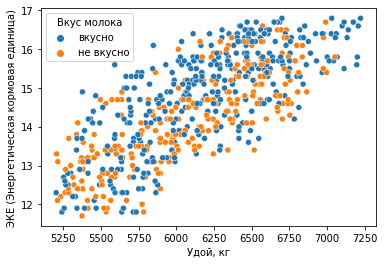

In [43]:
#Строю диаграмму рассеяния для параметров 'Удой, кг' и 'ЭКЕ (Энергетическая кормовая единица)' c учетом категориального параметра 'Вкус молока'
sns.scatterplot(data=farm_main_df, x='Удой, кг', y='ЭКЕ (Энергетическая кормовая единица)', hue='Вкус молока', sizes=(50, 50), legend=True);

**Вывод:** Вкус молока не имеет зависимости с удоем и ЭКЕ.

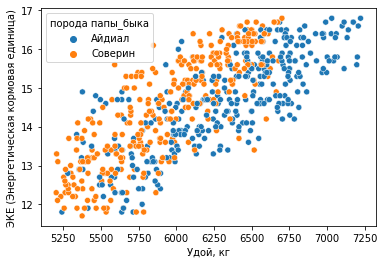

In [44]:
#Строю диаграмму рассеяния для параметров 'Удой, кг' и 'ЭКЕ (Энергетическая кормовая единица)' c учетом категориального параметра 'порода папы_быка'
sns.scatterplot(data=farm_main_df, x='Удой, кг', y='ЭКЕ (Энергетическая кормовая единица)', hue='порода папы_быка', sizes=(50, 50), legend=True);


**Вывод:** Порода папы быка Айдиал имеют более высокие значения по ЭКЕ и удою по сравнению с породой Соверин.

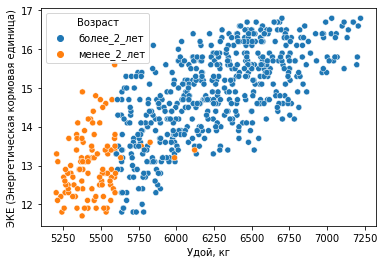

In [45]:
#Строю диаграмму рассеяния для параметров 'Удой, кг' и 'ЭКЕ (Энергетическая кормовая единица)' c учетом категориального параметра 'Возраст'
sns.scatterplot(data=farm_main_df, x='Удой, кг', y='ЭКЕ (Энергетическая кормовая единица)', hue='Возраст', sizes=(50, 50), legend=True);


**Вывод:** Удой коров в возрасте до 2 лет варьируется от 5375 до 5600 литров, тогда как у коров старше 2 лет он колеблется в более широком диапазоне — от 5600 до 7250 литров. Кроме того, значение ЭКЕ выше у коров, не достигших 2 лет.

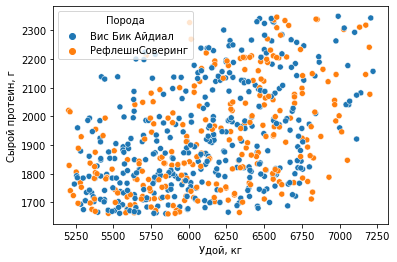

In [46]:
#Строю диаграмму рассеяния для параметров 'Удой, кг' и 'Cырой протеин, г' c учетом категориального параметра 'Порода'
sns.scatterplot(data=farm_main_df, x='Удой, кг', y='Сырой протеин, г', hue='Порода', sizes=(50, 50), legend=True);

**Вывод:** Порода не оказывает значительного влияния на удой и содержание сырого протеина.

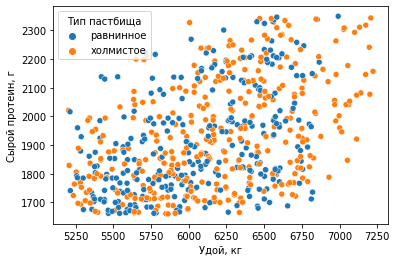

In [47]:
#Строю диаграмму рассеяния для параметров 'Удой, кг' и 'Cырой протеин, г' c учетом категориального параметра 'Тип пастбища'
sns.scatterplot(data=farm_main_df, x='Удой, кг', y='Сырой протеин, г', hue='Тип пастбища', sizes=(50, 50), legend=True);

**Вывод:** Тип пастбища не оказывает значительного влияния на удой и содержание сырого протеина. Однако можно отметить, что изменения удоя в пределах 6875-7250 кг наблюдаются только на холмистых пастбищах.

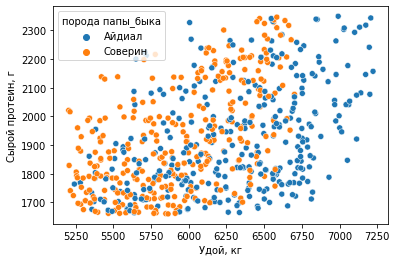

In [48]:
#Строю диаграмму рассеяния для параметров 'Удой, кг' и 'Cырой протеин, г' c учетом категориального параметра 'порода папы_быка'
sns.scatterplot(data=farm_main_df, x='Удой, кг', y='Сырой протеин, г', hue='порода папы_быка', sizes=(50, 50), legend=True);

**Вывод:** Удой коров, у которых порода папы породы Соверин, в основном колеблется в пределах от 5125 до 6250 кг. В то время как удой коров, чьи отцы — быки породы Айдиал, распределен более равномерно по всему диапазону от 5125 до 7250 кг. Кроме того, стоит отметить, что значения сырого протеина у коров, чьи папы породы Соверин, сосредоточены в пределах 1650-2000.

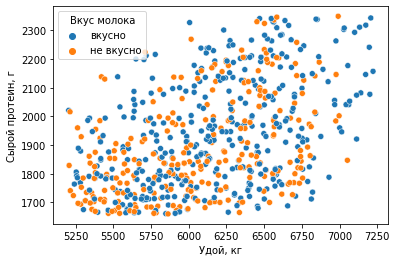

In [49]:
#Строю диаграмму рассеяния для параметров 'Удой, кг' и 'Cырой протеин, г' c учетом категориального параметра 'Вкус молока'
sns.scatterplot(data=farm_main_df, x='Удой, кг', y='Сырой протеин, г', hue='Вкус молока', sizes=(50, 50), legend=True);

**Вывод:** Удой и содержание сырого протеина не оказывают значительного влияния на вкус молока. Однако можно отметить, что при удое в диапазоне 7000-7250 кг и СПО в интервале 1900-2400 молоко чаще оказывается вкусным.

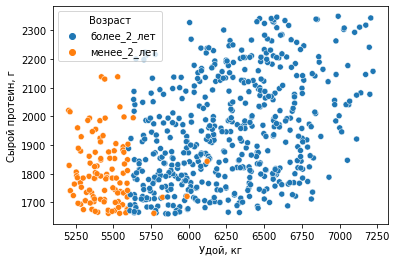

In [50]:
#Строю диаграмму рассеяния для параметров 'Удой, кг' и 'Cырой протеин, г' c учетом категориального параметра 'Возраст'
sns.scatterplot(data=farm_main_df, x='Удой, кг', y='Сырой протеин, г', hue='Возраст', sizes=(50, 50), legend=True);

**Вывод:** Удой коров младше 2 лет варьируется в пределах 5125–5600 кг, тогда как у коров старше 2 лет он изменяется в более широком диапазоне — от 5600 до 7250 кг. Содержание сырого протеина у коров младше 2 лет составляет 1600–2000 г, тогда как у более взрослых животных этот показатель колеблется от 1600 до 2400 г.

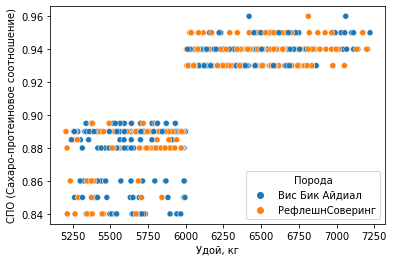

In [51]:
#Строю диаграмму рассеяния для параметров 'Удой, кг' и 'СПО (Сахаро-протеиновое соотношение)' c учетом категориального параметра 'Порода'
sns.scatterplot(data=farm_main_df, x='Удой, кг', y='СПО (Сахаро-протеиновое соотношение)', hue='Порода', sizes=(50, 50), legend=True);

**Вывод:** Порода не оказывает влияния на удой и СПО. Однако при удое в пределах 5125–6000 кг наблюдаются два диапазона значений СПО: 0.84–0.86 и 0.88–0.9. В то же время при удое от 6000 до 7250 кг СПО варьируется в диапазоне 0.92–0.96.

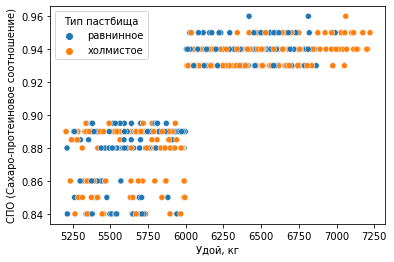

In [52]:
#Строю диаграмму рассеяния для параметров 'Удой, кг' и 'CПО(Сахаро-протеиновое соотношение)' c учетом категориального параметра 'Тип пастбища'
sns.scatterplot(data=farm_main_df, x='Удой, кг', y='СПО (Сахаро-протеиновое соотношение)', hue='Тип пастбища', sizes=(50, 50), legend=True);

**Вывод:** Тип пастбища не оказывает сильного влияния на удой и СПО.

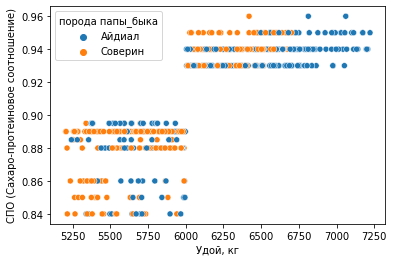

In [53]:
#Строю диаграмму рассеяния для параметров 'Удой, кг' и 'CПО(Сахаро-протеиновое соотношение)' c учетом категориального параметра 'порода папы_быка'
sns.scatterplot(data=farm_main_df, x='Удой, кг', y='СПО (Сахаро-протеиновое соотношение)', hue='порода папы_быка', sizes=(50, 50), legend=True);

**Вывод:** Порода папы быка не влияет на СПО. Удой коров, происходящих от быков породы Айдиал изменяется в более широких пределах.

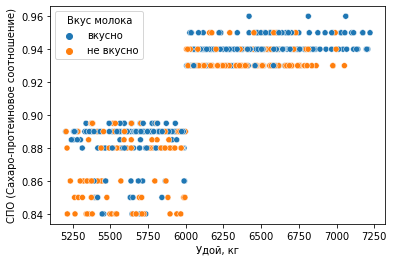

In [54]:
#Строю диаграмму рассеяния для параметров 'Удой, кг' и 'CПО(Сахаро-протеиновое соотношение)' c учетом категориального параметра 'Вкус молока'
sns.scatterplot(data=farm_main_df, x='Удой, кг', y='СПО (Сахаро-протеиновое соотношение)', hue='Вкус молока', sizes=(50, 50), legend=True);

**Вывод:** СПО и Удой не влияют на вкус молока. Однако можно отметить, что молоко с СПО в пределах 0.92-0.93 часто оказывается невкусным.

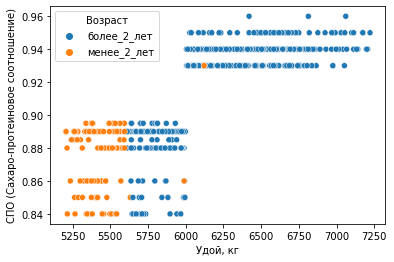

In [55]:
#Строю диаграмму рассеяния для параметров 'Удой, кг' и 'CПО(Сахаро-протеиновое соотношение)' c учетом категориального параметра 'Возраст'
sns.scatterplot(data=farm_main_df, x='Удой, кг', y='СПО (Сахаро-протеиновое соотношение)', hue='Возраст', sizes=(50, 50), legend=True);

**Вывод:** У коров в возрасте менее 2 лет и с удоем в диапазоне 5125–5600 кг значение СПО распределено в двух диапазонах: 0.84–0.86 и 0.88–0.9. У коров старшего возраста, имеющих удой от 5600 до 7250 кг, к этим диапазонам СПО добавляется еще один — 0.92–0.96.

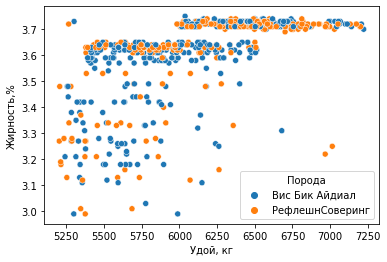

In [56]:
#Строю диаграмму рассеяния для параметров 'Удой, кг' и 'Жирность,%' c учетом категориального параметра 'Порода'
sns.scatterplot(data=farm_main_df, x='Удой, кг', y='Жирность,%', hue='Порода', sizes=(50, 50), legend=True);

**Вывод:** Порода и удой не влияют на жирность.

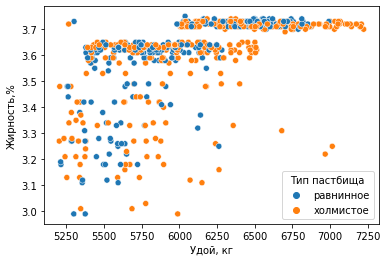

In [57]:
#Строю диаграмму рассеяния для параметров 'Удой, кг' и 'Жирность,%' c учетом категориального параметра 'Тип пастбища'
sns.scatterplot(data=farm_main_df, x='Удой, кг', y='Жирность,%', hue='Тип пастбища', sizes=(50, 50), legend=True);

**Вывод:** Тип пастбища не влияет на удой и жирность.

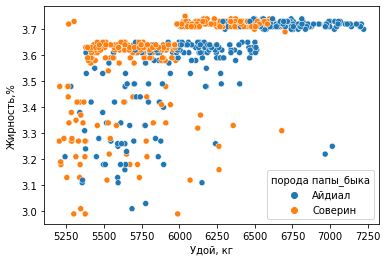

In [58]:
#Строю диаграмму рассеяния для параметров 'Удой, кг' и 'Жирность,%' c учетом категориального параметра 'порода папы_быка'
sns.scatterplot(data=farm_main_df, x='Удой, кг', y='Жирность,%', hue='порода папы_быка', sizes=(50, 50), legend=True);

**Вывод:** Порода папы быка не влияет на жирность

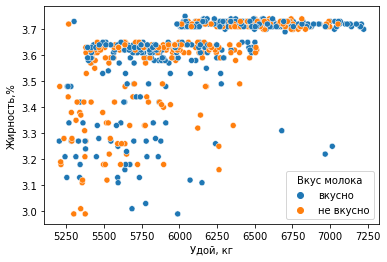

In [59]:
#Строю диаграмму рассеяния для параметров 'Удой, кг' и 'Жирность,%' c учетом категориального параметра 'Вкус молока'
sns.scatterplot(data=farm_main_df, x='Удой, кг', y='Жирность,%', hue='Вкус молока', sizes=(50, 50), legend=True);

**Вывод:** Жирность и удой не влияют на вкус молока.

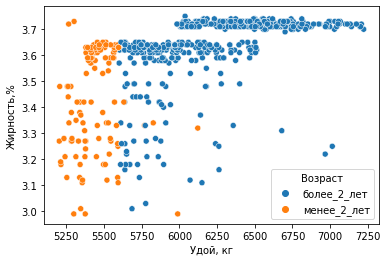

In [60]:
#Строю диаграмму рассеяния для параметров 'Удой, кг' и 'Жирность,%' c учетом категориального параметра 'Возраст'
sns.scatterplot(data=farm_main_df, x='Удой, кг', y='Жирность,%', hue='Возраст', sizes=(50, 50), legend=True);

**Вывод:**  У коров в возрасте менее 2 лет и с удоем в диапазоне 5125–5600 кг уровень жирности распределен в двух диапазонах: более рассеяно в 3.0-3.5% и концентрировано в 0.88–0.9%. У коров старшего возраста, имеющих удой от 5600 до 7250 кг, к этим диапазонам жирности добавляется еще один — около 3.7%.

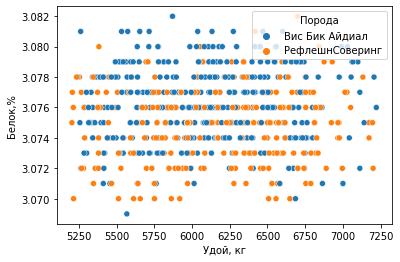

In [61]:
#Строю диаграмму рассеяния для параметров 'Удой, кг' и 'Белок,%' c учетом категориального параметра 'Порода'
sns.scatterplot(data=farm_main_df, x='Удой, кг', y='Белок,%', hue='Порода', sizes=(50, 50), legend=True);

**Вывод:** Порода не влияет на удой и содержание белка.

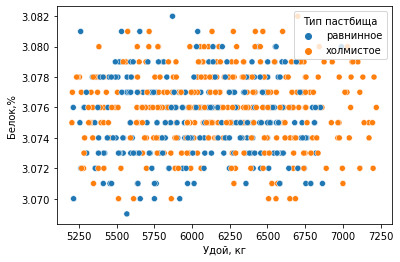

In [62]:
#Строю диаграмму рассеяния для параметров 'Удой, кг' и 'Белок,%' c учетом категориального параметра 'Тип пастбища'
sns.scatterplot(data=farm_main_df, x='Удой, кг', y='Белок,%', hue='Тип пастбища', sizes=(50, 50), legend=True);

**Вывод:** Тип пастбища не оказывает влиянися на содержание белка. Однако стоит отметить, что для только для холмистого типа пастбищ наблюдается изменение удоя в пределах 6875-7250 кг.

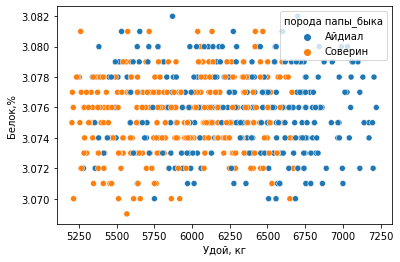

In [63]:
#Строю диаграмму рассеяния для параметров 'Удой, кг' и 'Белок,%' c учетом категориального параметра 'порода папы_быка'
sns.scatterplot(data=farm_main_df, x='Удой, кг', y='Белок,%', hue='порода папы_быка', sizes=(50, 50), legend=True);

**Вывод:** Порода папы быка не оказывает влияния на уровень белка.

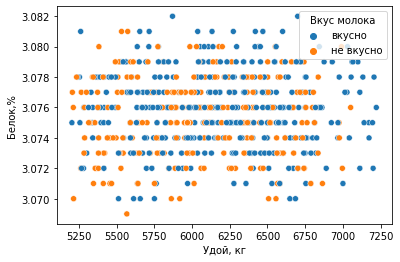

In [64]:
#Строю диаграмму рассеяния для параметров 'Удой, кг' и 'Белок,%' c учетом категориального параметра 'порода папы_быка'
sns.scatterplot(data=farm_main_df, x='Удой, кг', y='Белок,%', hue='Вкус молока', sizes=(50, 50), legend=True);

**Вывод:** Уровень белка и удой не влияют на вкус молока.

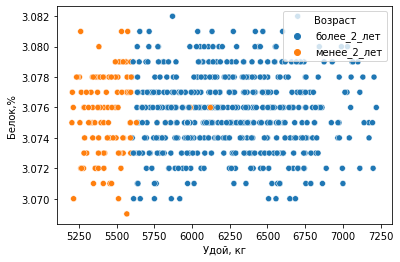

In [65]:
#Строю диаграмму рассеяния для параметров 'Удой, кг' и 'Белок,%' c учетом категориального параметра 'Возраст'
sns.scatterplot(data=farm_main_df, x='Удой, кг', y='Белок,%', hue='Возраст', sizes=(50, 50), legend=True);

**Вывод:** Возраст не влияет на содержание белка.

**Общие выводы:** Между входными признаками нет мультиколлинеарности. Между удоем и ЭКЕ, как и между удоем и содержанием сырого протеина наблюдается зависимость, близкая к линейной. Более того, график не отображает линейной связи между удоем и СПО, как и между удоем и жирностью, что может свидетельствовать о наличии нелинейной связи или отсутствии связи. Данный анализ данных также не выявил связи между удоем и содержанием белка.

## Обучение моделей линейной регрессии для прогноза удоя

In [66]:
#Строю первую модель линейной регрессии на начальных данных
#Создание константы RANDOM_STATE
RANDOM_STATE = 42

#Выделяю в отдельные переменные целевой признак и входные признаки, исключив характеристики молока и столбец 'id'
X = farm_main_df.drop(columns=['Удой, кг', 'Вкус молока','id', 'Жирность,%', 'Белок,%' ])
y = farm_main_df['Удой, кг']

#Разделяю данные на тренировочные и тестовые, фиксирую при этом random_state
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)

#Создаю списки категориальных и количественных признаков тренировочной выборки
cat_col_names = ['Порода', 'порода папы_быка', 'Тип пастбища', 'Возраст']
num_col_names = ['Сырой протеин, г', 'ЭКЕ (Энергетическая кормовая единица)', 'СПО (Сахаро-протеиновое соотношение)']

#Масштабирую категориальные признаки из тренировочной и тестовой выборок
encoder = OneHotEncoder(drop='first', sparse=False)
X_train_ohe = encoder.fit_transform(X_train[cat_col_names])
X_test_ohe = encoder.transform(X_test[cat_col_names])

#Сохраняю названия новых столбцов для категориальных признаков в новой переменной
encoder_col_names = encoder.get_feature_names()

#Масштабирую количественные признаки из тренировочной и тестовой выборок
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[num_col_names])
X_test_scaled = scaler.transform(X_test[num_col_names]) 

#Заменяю данные в датафреймах X_train и X_test на отмасштабированные данные
X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names)

X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)

#Инициализирую модель линейной регрессии
model_lr = LinearRegression()

#Обучаю модель на тренировочных данных
model_lr.fit(X_train, y_train)

#Сохраняю результат предсказания в переменную predictions
predictions = model_lr.predict(X_test)

In [67]:
#Рассчитываю значения R2 для модели линейной регрессии 1
r2 = r2_score(y_test, predictions)

print("R2 линейной модели №1 =", r2)

R2 линейной модели №1 = 0.8156912783460437


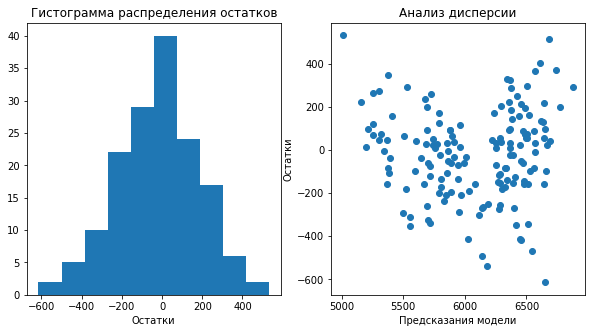

In [68]:
#Делаю анализ остатков для модели 1
residuals = y_test - predictions

#Строю гистограмму частотности распределения и диаграмму рассеяния
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5))
axes[0].hist(residuals)
axes[0].set_title('Гистограмма распределения остатков')
axes[0].set_xlabel('Остатки')

axes[1].scatter(x=predictions, y=residuals)
axes[1].set_xlabel('Предсказания модели')
axes[1].set_ylabel('Остатки')
axes[1].set_title('Анализ дисперсии')
plt.show()

**Вывод:** Значение R^2 для первой модели = 0.82, что указывает на довольно высокую точность предсказания, однако при анализе остатков на диаграмме  рассеяния видим, что остатки образуют 'V'-образную форму, что может указывать на то, что модель хуже предсказывает для больших и маленьких значений, а ошибки растут с увеличением предсказанного значения.

In [69]:
#Строю вторую модель линейной регрессии на данных с добавлением признаков ЭКЕ^2 и СПО_категория
#Добавляю новый признак 'ЭКЕ (Энергетическая кормовая единица)^2' в датафрейм
farm_main_df['ЭКЕ (Энергетическая кормовая единица)^2'] = farm_main_df['ЭКЕ (Энергетическая кормовая единица)'] **2
#Преобразую СПО в категориальный бинарный признак, использовав значение 0.91 в качестве границы
farm_main_df["СПО_категория"] = (farm_main_df["СПО (Сахаро-протеиновое соотношение)"] > 0.91).astype(int)

#Создание константы RANDOM_STATE
RANDOM_STATE = 42

#Выделяю в отдельные переменные целевой признак и входные признаки, исключив характеристики молока и столбец 'id'
X_1 = farm_main_df.drop(columns=['Удой, кг', 'ЭКЕ (Энергетическая кормовая единица)', 'СПО (Сахаро-протеиновое соотношение)', 'Вкус молока', 'Жирность,%', 'Белок,%', 'id'])
y_1 = farm_main_df['Удой, кг']

#Разделяю данные на тренировочные и тестовые, фиксирую при этом random_stat
X_1_train, X_1_test, y_1_train, y_1_test = train_test_split(X_1, y_1, test_size=0.25, random_state=RANDOM_STATE)

#Создаю списки категориальных и количественных признаков тренировочной выборки
cat_col_names_1 = ['Порода', 'порода папы_быка', 'Тип пастбища',  'Возраст', 'СПО_категория']
num_col_names_1 = ['Сырой протеин, г','ЭКЕ (Энергетическая кормовая единица)^2']

#Сохраняю названия новых столбцов для категориальных признаков в новой переменной
encoder_1 = OneHotEncoder(drop='first', sparse=False)
X_1_train_ohe = encoder_1.fit_transform(X_1_train[cat_col_names_1])
X_1_test_ohe = encoder_1.transform(X_1_test[cat_col_names_1])

encoder_col_names_1 = encoder_1.get_feature_names()

#Масштабирую количественные признаки из тренировочной и тестовой выборок
scaler_1 = StandardScaler()
X_1_train_scaled = scaler_1.fit_transform(X_1_train[num_col_names_1])
X_1_test_scaled = scaler_1.transform(X_1_test[num_col_names_1]) 

#Заменяю данные в датафреймах X_train и X_test на отмасштабированные данные
X_1_train_ohe = pd.DataFrame(X_1_train_ohe, columns=encoder_col_names_1)
X_1_test_ohe = pd.DataFrame(X_1_test_ohe, columns=encoder_col_names_1)

X_1_train_scaled = pd.DataFrame(X_1_train_scaled, columns=num_col_names_1)
X_1_test_scaled = pd.DataFrame(X_1_test_scaled, columns=num_col_names_1)

X_1_train = pd.concat([X_1_train_ohe, X_1_train_scaled], axis=1)
X_1_test = pd.concat([X_1_test_ohe, X_1_test_scaled], axis=1)

#Инициализирую модель линейной регрессии
model_lr_1  = LinearRegression()

#Обучаю модель на тренировочных данных
model_lr_1.fit(X_1_train, y_1_train)

#Сохраняю результат предсказания в переменную predictions
predictions_1 = model_lr_1.predict(X_1_test)

In [70]:
#Рассчитываю значения R2 для модели линейной регрессии 2
r2_1 = r2_score(y_1_test, predictions_1)

print("R2 линейной модели №2 =", r2_1)

R2 линейной модели №2 = 0.8408887071869032


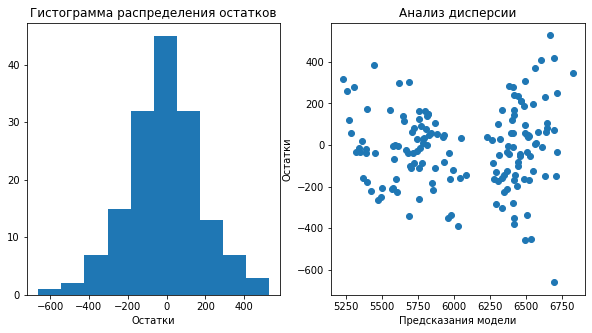

In [71]:
#Делаю анализ остатков для модели 2
residuals_1 = y_1_test - predictions_1

#Строю гистограмму частотности распределения и диаграмму рассеяния
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5))
axes[0].hist(residuals_1)
axes[0].set_title('Гистограмма распределения остатков')
axes[0].set_xlabel('Остатки')

axes[1].scatter(x=predictions_1, y=residuals_1)
axes[1].set_xlabel('Предсказания модели')
axes[1].set_ylabel('Остатки')
axes[1].set_title('Анализ дисперсии')
plt.show()

**Вывод:** Значение R² для второй модели увеличилось до 0.84 после добавления нового признака (ЭКЕ в квадрате) и преобразования СПО в категориальный бинарный признак. Кроме того, анализ диаграммы рассеяния остатков показывает, что график теряет 'V'-образную форму, что свидетельствует о повышении качества предсказаний модели.

In [72]:
#Объединяю датафреймы farm_main_df и farm_dad_df в один
farm_main_df = pd.merge(farm_main_df, farm_dad_df, on='id', how='left')
display(farm_main_df)

,id,"Удой, кг",ЭКЕ (Энергетическая кормовая единица),"Сырой протеин, г",СПО (Сахаро-протеиновое соотношение),Порода,Тип пастбища,порода папы_быка,"Жирность,%","Белок,%",Вкус молока,Возраст,ЭКЕ (Энергетическая кормовая единица)^2,СПО_категория,Имя Папы
0,1,5863,14.2,1743,0.890,Вис Бик Айдиал,равнинное,Айдиал,3.58,3.076,вкусно,более_2_лет,201.64,0,Буйный
1,2,5529,12.8,2138,0.890,Вис Бик Айдиал,равнинное,Соверин,3.54,3.079,вкусно,менее_2_лет,163.84,0,Соловчик
2,3,5810,14.0,1854,0.885,РефлешнСоверинг,холмистое,Соверин,3.59,3.074,не вкусно,более_2_лет,196.00,0,Барин
3,4,5895,12.4,2012,0.885,РефлешнСоверинг,холмистое,Айдиал,3.40,3.075,не вкусно,более_2_лет,153.76,0,Буйный
4,5,5302,12.8,1675,0.885,Вис Бик Айдиал,равнинное,Соверин,3.73,3.073,вкусно,менее_2_лет,163.84,0,Барин
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
623,627,5970,14.4,1837,0.880,РефлешнСоверинг,холмистое,Соверин,3.64,3.075,не вкусно,более_2_лет,207.36,0,Барин
624,627,5970,14.4,1837,0.880,РефлешнСоверинг,холмистое,Соверин,3.64,3.075,не вкусно,более_2_лет,207.36,0,Барин
625,627,5970,14.4,1837,0.880,РефлешнСоверинг,холмистое,Соверин,3.64,3.075,не вкусно,более_2_лет,207.36,0,Барин
626,627,5970,14.4,1837,0.880,РефлешнСоверинг,холмистое,Соверин,3.64,3.075,не вкусно,более_2_лет,207.36,0,Барин


In [73]:
#Создание константы RANDOM_STATE
RANDOM_STATE = 42

#Выделяю в отдельные переменные целевой признак и входные признаки, исключив характеристики молока и столбец 'id'
X_2 = farm_main_df.drop(columns=['Удой, кг', 'ЭКЕ (Энергетическая кормовая единица)', 'СПО (Сахаро-протеиновое соотношение)', 'Жирность,%', 'Белок,%', 'id', 'Вкус молока'])
y_2 = farm_main_df['Удой, кг']

#Разделяю данные на тренировочные и тестовые, фиксирую при этом random_stat
X_2_train, X_2_test, y_2_train, y_2_test = train_test_split(X_2, y_2, test_size=0.25, random_state=RANDOM_STATE)

#Создаю списки категориальных и количественных признаков тренировочной выборки
cat_col_names_2 = ['Порода', 'порода папы_быка', 'Тип пастбища', 'Возраст', 'СПО_категория', 'Имя Папы']
num_col_names_2 = ['Сырой протеин, г','ЭКЕ (Энергетическая кормовая единица)^2']

#Сохраняю названия новых столбцов для категориальных признаков в новой переменной
encoder_2 = OneHotEncoder(drop='first', sparse=False)
X_2_train_ohe = encoder_2.fit_transform(X_2_train[cat_col_names_2])
X_2_test_ohe = encoder_2.transform(X_2_test[cat_col_names_2])

encoder_col_names_2 = encoder_2.get_feature_names()

#Масштабирую количественные признаки из тренировочной и тестовой выборок
scaler_2 = StandardScaler()
X_2_train_scaled = scaler_2.fit_transform(X_2_train[num_col_names_2])
X_2_test_scaled = scaler_2.transform(X_2_test[num_col_names_2]) 

#Заменяю данные в датафреймах X_train и X_test на отмасштабированные данные
X_2_train_ohe = pd.DataFrame(X_2_train_ohe, columns=encoder_col_names_2)
X_2_test_ohe = pd.DataFrame(X_2_test_ohe, columns=encoder_col_names_2)

X_2_train_scaled = pd.DataFrame(X_2_train_scaled, columns=num_col_names_2)
X_2_test_scaled = pd.DataFrame(X_2_test_scaled, columns=num_col_names_2)

X_2_train = pd.concat([X_2_train_ohe, X_2_train_scaled], axis=1)
X_2_test = pd.concat([X_2_test_ohe, X_2_test_scaled], axis=1)


#Инициализирую модель линейной регрессии
model_lr_2  = LinearRegression()

#Обучаю модель на тренировочных данных
model_lr_2.fit(X_2_train, y_2_train)

#Сохраняю результат предсказания в переменную predictions
predictions_2 = model_lr_2.predict(X_2_test)


In [74]:
#Рассчитываю значения R2 для модели линейной регрессии 3
r2_2 = r2_score(y_2_test, predictions_2)

print("R2 линейной модели №3 =", r2_2) 

R2 линейной модели №3 = 0.8501510764075351


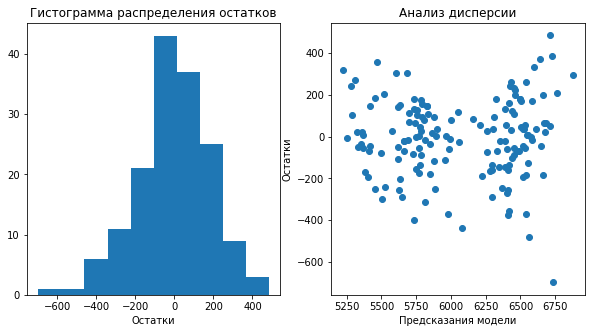

In [75]:
#Делаю анализ остатков
residuals_2 = y_2_test - predictions_2

#Строю гистограмму частотности распределения и диаграмму рассеяния
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5))
axes[0].hist(residuals_2)
axes[0].set_title('Гистограмма распределения остатков')
axes[0].set_xlabel('Остатки')

axes[1].scatter(x=predictions_2, y=residuals_2)
axes[1].set_xlabel('Предсказания модели')
axes[1].set_ylabel('Остатки')
axes[1].set_title('Анализ дисперсии')
plt.show()

**Вывод:** По сравнению со второй моделью, значение R² в третьей модели увеличилось до 0.85 после добавления информации об именах отцов быков. Кроме того, гистограмма распределения остатков стала наиболее приближенной к нормальному распределению, а диаграмма рассеяния остатков показывает, что график сильно утратил 'V'-образную форму, что дополнительно служит подтвеждением повышения качества предсказаний модели.

In [76]:
#Создаю функцию для подсчета rsme
def get_rmse(a, b):
    res = np.sqrt(np.mean((np.array(a) - np.array(b))**2))
    return res

## Выбор лучшей модели

In [77]:
#Рассчитываю значения mae, rmse, mse для первой модели
print('Значение MAE для модели 1:', mean_absolute_error(y_test, predictions))
print('Значение RMSE для модели 1:', get_rmse(y_test, predictions))
print('Значение MSE для модели 1:', mean_squared_error(y_test, predictions))

Значение MAE для модели 1: 162.04040129642658
Значение RMSE для модели 1: 206.4233365063678
Значение MSE для модели 1: 42610.59385442116


In [78]:
#Рассчитываю значения mae, rmse, mse для второй модели
print('Значение MAE для модели 2:', mean_absolute_error(y_1_test, predictions_1))
print('Значение RMSE для модели 2:', get_rmse(y_1_test, predictions_1))
print('Значение MSE для модели 2:', mean_squared_error(y_1_test, predictions_1))

Значение MAE для модели 2: 148.18692547120244
Значение RMSE для модели 2: 191.79458977659792
Значение MSE для модели 2: 36785.16466757348


In [79]:
#Рассчитываю значения mae, rmse, mse для третьей модели
print('Значение MAE для модели 3:', mean_absolute_error(y_2_test, predictions_2))
print('Значение RMSE для модели 3:', get_rmse(y_2_test, predictions_2))
print('Значение MSE для модели 3:', mean_squared_error(y_2_test, predictions_2))

Значение MAE для модели 3: 142.848352324109
Значение RMSE для модели 3: 186.12840846136268
Значение MSE для модели 3: 34643.78443635987


**Вывод:** Лучшая модель — третья, так как для неё наблюдаются наименьшие значения по всем трём метрикам.

In [80]:
#Рассчитываю квантили ошибок для доверительного интервала
predictions_train = model_lr_2.predict(X_2_train)
residuals_train = y_2_train - predictions_train
lower_bound = np.percentile(residuals_train, 2.5)  #2.5% перцентиль (нижняя граница)
upper_bound = np.percentile(residuals_train, 97.5) #97.5% перцентиль (верхняя граница)

#Расчет 95% доверительного интервала прогноза лучшей модели

prediction_lower = np.mean(predictions_train + lower_bound)
prediction_upper = np.mean(predictions_train + upper_bound)

print(f"Доверительный интервал третьей модели: {prediction_lower:.2f} - {prediction_upper:.2f}")

Доверительный интервал третьей модели: 5821.31 - 6528.73


## Прогноз удоя коров

In [81]:
#Добавляю недостоющие признаки из farm_main_df в cow_buy_df
cow_buy_df['ЭКЕ (Энергетическая кормовая единица)^2'] = ((farm_main_df['ЭКЕ (Энергетическая кормовая единица)'].mean())*1.05)**2
cow_buy_df["СПО_категория"] = (farm_main_df["СПО (Сахаро-протеиновое соотношение)"] > 0.91).astype(int)
cow_buy_df['Сырой протеин, г'] = farm_main_df['Сырой протеин, г'].mean()*1.05
#Меняю названия столбцов
cow_buy_df.rename(columns={'Текущая_жирность,%':'Жирность,%'}, inplace=True)
cow_buy_df.rename(columns={'Текущий_уровень_белок,%':'Белок,%'}, inplace=True)
cow_buy_df.rename(columns={'Имя_папы':'Имя Папы'}, inplace=True)

In [82]:
display(cow_buy_df)

,Порода,Тип пастбища,порода папы_быка,Имя Папы,"Жирность,%","Белок,%",Возраст,ЭКЕ (Энергетическая кормовая единица)^2,СПО_категория,"Сырой протеин, г"
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет,233.698406,0,2018.969427
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет,233.698406,0,2018.969427
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет,233.698406,0,2018.969427
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет,233.698406,0,2018.969427
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет,233.698406,0,2018.969427
5,РефлешнСоверинг,равнинное,Соверин,Геркулес,3.63,3.053,менее_2_лет,233.698406,0,2018.969427
6,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет,233.698406,0,2018.969427
7,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.57,3.079,более_2_лет,233.698406,1,2018.969427
8,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет,233.698406,1,2018.969427
9,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.079,менее_2_лет,233.698406,0,2018.969427


In [83]:
#Исключаю характеристики молока и столбец 'id'
X_3 = cow_buy_df.drop(columns=['Жирность,%', 'Белок,%'])

#Масштабирую категориальные признаки из тренировочной и тестовой выборок
X_3_ohe = encoder_2.transform(X_3[cat_col_names_2])

#Сохраняю названия новых столбцов для категориальных признаков в новой переменной
encoder_col_names_3 = encoder_2.get_feature_names()

#Масштабирую количественные признаки из тренировочной и тестовой выборок
X_3_scaled = scaler_2.transform(X_3[num_col_names_2]) 

#Заменяю данные в датафреймах X_train и X_test на отмасштабированные данные
X_3_ohe = pd.DataFrame(X_3_ohe, columns=encoder_col_names_2)
X_3_scaled = pd.DataFrame(X_3_scaled, columns=num_col_names_2)

X_3 = pd.concat([X_3_ohe, X_3_scaled], axis=1)

#Сохраняю результат предсказания удоя в переменную predictions
predictions_3 = model_lr_2.predict(X_3)

#Считаю кол-во подходящих коров
count=0
for i in predictions_3:
    if i> 6000:
        count+=1
print('Кол-во подходящих коров по удою:', count)

Кол-во подходящих коров по удою: 17


**Вывод:** Фермеру по удою подходят 17 коров из 'Экофермы'. 

## Обучение модели логистической регрессии для прогноза вкуса молока

In [84]:
#Создание константы RANDOM_STATE
RANDOM_STATE = 42

#Выделяю в отдельные переменные целевой признак и входные признаки, исключив параметры 'Вкус молока', 'ЭКЕ (Энергетическая кормовая единица)' и 'СПО (Сахаро-протеиновое соотношение)'
X_4 = farm_main_df.drop(columns=['Вкус молока', 'ЭКЕ (Энергетическая кормовая единица)'])
y_4 = farm_main_df['Вкус молока'].apply(lambda x: 1 if  x=='вкусно' else 0) #вкусно принимаем за 1

#Разделяю данные на тренировочные и тестовые, фиксирую при этом random_stat
X_4_train, X_4_test, y_4_train, y_4_test = train_test_split(X_4, y_4, test_size=0.25, random_state=RANDOM_STATE)

#Создаю списки категориальных и количественных признаков тренировочной выборки
cat_col_names_4 = ['Порода', 'порода папы_быка', 'Тип пастбища', 'Возраст', 'Имя Папы']
num_col_names_4 = ['Сырой протеин, г', 'Жирность,%', 'Белок,%','ЭКЕ (Энергетическая кормовая единица)^2', 'СПО (Сахаро-протеиновое соотношение)', 'Удой, кг']

#Сохраняю названия новых столбцов для категориальных признаков в новой переменной
encoder_4 = OneHotEncoder(drop='first', sparse=False)
X_4_train_ohe = encoder_4.fit_transform(X_4_train[cat_col_names_4])
X_4_test_ohe = encoder_4.transform(X_4_test[cat_col_names_4])

encoder_col_names_4 = encoder_4.get_feature_names()

#Масштабирую количественные признаки из тренировочной и тестовой выборок
scaler_4 = StandardScaler()
X_4_train_scaled = scaler_4.fit_transform(X_4_train[num_col_names_4])
X_4_test_scaled = scaler_4.transform(X_4_test[num_col_names_4]) 

#Заменяю данные в датафреймах X_train и X_test на отмасштабированные данные
X_4_train_ohe = pd.DataFrame(X_4_train_ohe, columns=encoder_col_names_4)
X_4_test_ohe = pd.DataFrame(X_4_test_ohe, columns=encoder_col_names_4)

X_4_train_scaled = pd.DataFrame(X_4_train_scaled, columns=num_col_names_4)
X_4_test_scaled = pd.DataFrame(X_4_test_scaled, columns=num_col_names_4)

X_4_train = pd.concat([X_4_train_ohe, X_4_train_scaled], axis=1)
X_4_test = pd.concat([X_4_test_ohe, X_4_test_scaled], axis=1)

#Создаю модель, обучаю её и получаю прогнозные значения
clf = LogisticRegression()
clf_4 = clf.fit(X_4_train, y_4_train) 
y_4_pred = clf_4.predict(X_4_test)

In [85]:
#Считаю метрику accuracy
accuracy = accuracy_score(y_4_test, y_4_pred)
print('Значение метрики accuracy =', accuracy)

Значение метрики accuracy = 0.5987261146496815


In [86]:
#Считаю метрику recall
recall = recall_score(y_4_test, y_4_pred)
print('Значение метрики recall =', recall)

Значение метрики recall = 0.7528089887640449


In [87]:
#Считаю метрику precision
precision = precision_score(y_4_test, y_4_pred)
print('Значение метрики precision =', precision)

Значение метрики precision = 0.6203703703703703


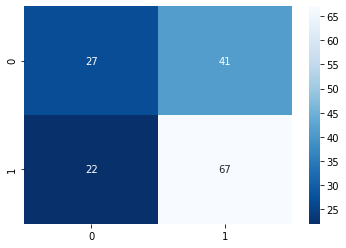

In [88]:
#Строю матрицу ошибок и сохраняю её в переменную cm
cm = confusion_matrix(y_4_test, y_4_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r');

**Вывод:** Accuracy (0.599) указывает на средний уровень качества модели. При этом recall (0.75) превышает precision (0.62), что означает что модель чаще ошибочно предсказывает вкусное молоко (1) там где оно на самом деле невкусное (0) — то есть допускает ложноположительные срабатывания (FP).
В контексте задачи это критическая ошибка: фермер получит корову, молоко которой модель признала вкусным, а по факту оно не соответствует его стандартам.

Следовательно приоритетная метрика для оптимизации — precision: важно минимизировать количество случаев когда модель ошибочно одобряет корову с невкусным молоком. Лучше пропустить хорошую корову (FN), чем купить неподходящую (FP).

In [89]:
#Подбираю порог для предсказания
#Получаю вероятности для каждого класса
probabilities_one_valid = clf_4.predict_proba(X_4_test)[:,1]

for i in np.arange(0.5, 0.9, 0.02).round(2):
    y_predict = probabilities_one_valid > i
    print('порог: ', i, 'precision: ', precision_score(y_4_test, y_predict))

порог:  0.5 precision:  0.6203703703703703
порог:  0.52 precision:  0.6274509803921569
порог:  0.54 precision:  0.6428571428571429
порог:  0.56 precision:  0.6593406593406593
порог:  0.58 precision:  0.7037037037037037
порог:  0.6 precision:  0.7105263157894737
порог:  0.62 precision:  0.75
порог:  0.64 precision:  0.7419354838709677
порог:  0.66 precision:  0.7454545454545455
порог:  0.68 precision:  0.78
порог:  0.7 precision:  0.7804878048780488
порог:  0.72 precision:  0.8333333333333334
порог:  0.74 precision:  0.8148148148148148
порог:  0.76 precision:  0.8636363636363636
порог:  0.78 precision:  0.8333333333333334
порог:  0.8 precision:  1.0
порог:  0.82 precision:  1.0
порог:  0.84 precision:  1.0
порог:  0.86 precision:  1.0
порог:  0.88 precision:  1.0


In [90]:
#Меняю порог значений на более оптимальный
y_probs = clf_4.predict_proba(X_4_test)[:,1]

threshold = 0.795
y_pred_4_w_th = (y_probs >= threshold).astype(int)

In [91]:
#Считаю метрику recall
recall = recall_score(y_4_test, y_pred_4_w_th)
print('Новое значение метрики recall =', recall)

Новое значение метрики recall = 0.14606741573033707


In [92]:
#Считаю метрику precision
precision = precision_score(y_4_test, y_pred_4_w_th)
print('Новое значение метрики precision =', precision)

Новое значение метрики precision = 0.9285714285714286


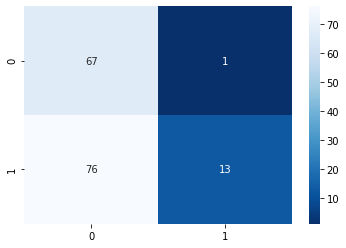

In [93]:
cm = confusion_matrix(y_4_test, y_pred_4_w_th)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r');

**Вывод:** После изменения порога предсказания до 0.795 precision вырос до 0.93, что означает что модель теперь крайне редко одобряет корову с невкусным молоком — именно то что нужно фермеру. Однако recall упал до 0.15: модель стала очень консервативной и отсеивает большинство коров, в том числе подходящих.
При данном пороге количество FN ошибок значительно превышает количество правильно предсказанных TP, что свидетельствует о низком общем качестве модели. Вероятная причина — недостаточное количество признаков или данных для обучения. С точки зрения бизнес-задачи выбранный порог является приемлемым компромиссом: фермер минимизирует риск купить корову с невкусным молоком, однако вынужден отклонять большое количество потенциально подходящих животных, что снижает эффективность отбора стада.

## Прогноз вкуса молока

In [94]:
#Добавляю прогнозы удоя коров «ЭкоФермы» в датафрейм с коровами, покупку которых рассматривает фермер и СПО, а также удаляю столбец СПО категория.
cow_buy_df['Удой, кг'] = predictions_3
cow_buy_df['СПО (Сахаро-протеиновое соотношение)'] = farm_main_df['СПО (Сахаро-протеиновое соотношение)']
cow_buy_df = cow_buy_df.drop(columns='СПО_категория')

In [95]:
display(cow_buy_df)

,Порода,Тип пастбища,порода папы_быка,Имя Папы,"Жирность,%","Белок,%",Возраст,ЭКЕ (Энергетическая кормовая единица)^2,"Сырой протеин, г","Удой, кг",СПО (Сахаро-протеиновое соотношение)
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет,233.698406,2018.969427,6226.976082,0.890
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет,233.698406,2018.969427,6001.579310,0.890
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет,233.698406,2018.969427,5931.099497,0.885
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет,233.698406,2018.969427,6243.560659,0.885
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет,233.698406,2018.969427,6190.311364,0.885
5,РефлешнСоверинг,равнинное,Соверин,Геркулес,3.63,3.053,менее_2_лет,233.698406,2018.969427,6063.831113,0.885
6,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет,233.698406,2018.969427,6226.976082,0.885
7,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.57,3.079,более_2_лет,233.698406,2018.969427,6560.324278,0.930
8,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет,233.698406,2018.969427,6297.695534,0.940
9,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.079,менее_2_лет,233.698406,2018.969427,6051.411728,0.895


In [96]:
#Выделяю в отдельные переменные целевой признак и входные признаки, исключив параметр 'ЭКЕ (Энергетическая кормовая единица)', так как между ним и удоем мультиколлинеарность
X_5 = cow_buy_df

#Масштабирую категориальные признаки из тренировочной и тестовой выборок
X_5_ohe = encoder_4.transform(X_5[cat_col_names_4])

#Сохраняю названия новых столбцов для категориальных признаков в новой переменной
encoder_col_names_5 = encoder_4.get_feature_names()

#Масштабирую количественные признаки из тренировочной и тестовой выборок
X_5_scaled = scaler_4.transform(X_5[num_col_names_4]) 

#Заменяю данные в датафреймах X_train и X_test на отмасштабированные данные
X_5_ohe = pd.DataFrame(X_5_ohe, columns=encoder_col_names_5)
X_5_scaled = pd.DataFrame(X_5_scaled, columns=num_col_names_4)

X_5 = pd.concat([X_5_ohe, X_5_scaled], axis=1)

#Меняю порог значений
y_5_probs = clf_4.predict_proba(X_5)[:,1]

#Сохраняю результат предсказания вкуса молока в переменную predictions
y_5_pred = (y_5_probs >= threshold).astype(int)

#Добавляю прогнозы вкуса молока в датафрейм с коровами, покупку которых рассматривает фермер.
cow_buy_df['Вкус молока'] = y_5_pred

**Вывод:** Для оценки качества модели использовались метрики accuracy, precision и recall. Приоритетной метрикой была выбрана precision, так как ключевой риск для фермера — купить корову с невкусным молоком. Качество модели ограничено объёмом обучающей выборки; результаты можно улучшить за счёт расширения датасета или добавления новых информативных признаков.

## Итоговый вывод

In [97]:
#Вывожу подходящие фермеру коровы
cow_buy_df = cow_buy_df.loc[(cow_buy_df['Удой, кг'] > 6000) & (cow_buy_df['Вкус молока'] == 1)]
display(cow_buy_df)

,Порода,Тип пастбища,порода папы_быка,Имя Папы,"Жирность,%","Белок,%",Возраст,ЭКЕ (Энергетическая кормовая единица)^2,"Сырой протеин, г","Удой, кг",СПО (Сахаро-протеиновое соотношение),Вкус молока
9,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.079,менее_2_лет,233.698406,2018.969427,6051.411728,0.895,1
13,Вис Бик Айдиал,холмистое,Соверин,Барин,3.42,3.075,менее_2_лет,233.698406,2018.969427,6119.377709,0.930,1


**Итоговый вывод:** В рамках проекта были разработаны две прогнозные модели для поддержки принятия решений о закупке коров в молочное хозяйство «Вольный луг».

Модель прогноза удоя (линейная регрессия, R²=0.85) показала высокое качество предсказания. Итеративное улучшение модели за счёт инжиниринга признаков — добавления ЭКЕ² и бинаризации СПО, а также включения родословной данных — позволило последовательно повысить R² с 0.82 до 0.85. Из 20 коров «ЭкоФермы» 17 соответствуют минимальному порогу удоя в 6000 кг в год.

Модель классификации вкуса молока (логистическая регрессия) показала средний уровень качества при стандартном пороге (accuracy=0.60). Поскольку приоритет фермера — не купить корову с невкусным молоком, а не максимизировать количество покупок, ключевой метрикой была выбрана precision. После оптимизации порога до 0.795 precision составил 0.93: модель одобряет корову только при высокой уверенности в качестве молока. Компромисс — низкий recall (0.15): большинство потенциально подходящих коров отсеивается, что снижает эффективность отбора.

По совокупности двух критериев из 20 кандидатов требованиям фермера соответствуют 2 коровы. Небольшое число рекомендованных животных объясняется консервативной стратегией классификации, которая намеренно минимизирует риск ошибочной покупки.

Ограничения модели связаны с небольшим объёмом обучающей выборки. Для повышения качества классификации рекомендуется расширить датасет и рассмотреть более сложные алгоритмы. Финальное решение о покупке следует принимать с учётом дополнительных факторов: стоимости животного, истории здоровья и долгосрочной продуктивности.